# EXPT NO: 7B
## DATA VISUALIZATION USING TABLEAU – IPL SPORTS ANALYTICS

### Aim
To import, transform, analyze, and visualize IPL ball-by-ball data using Tableau Desktop and create interactive dashboards and reports for decision-making.

The lab workflow specifies connecting to the dataset, checking/cleaning it, creating worksheets and bar/line/pie/table visualizations, combining them into a dashboard, and adding filters. fileciteturn32file1L45-L61


### Algorithm
1. Open Tableau Desktop.
2. Connect to the IPL CSV dataset.
3. Import and inspect the data.
4. Clean and transform required fields.
5. Create worksheets using suitable IPL fields.
6. Create bar, line, pie and table visualizations.
7. Combine worksheets into an interactive dashboard.
8. Add filters for Season, Batting Team and Venue.
9. Analyze the dashboard and identify important insights.
10. Save the Tableau workbook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("IPL_ball_by_ball_updated.csv")
df["start_date"]=pd.to_datetime(df["start_date"],errors="coerce")
df["total_runs"]=df["runs_off_bat"]+df["extras"].fillna(0)
df["boundary_runs"]=df["runs_off_bat"].where(df["runs_off_bat"].isin([4,6]),0)

print("Dataset loaded successfully")
print("Shape:",df.shape)
display(df.head())


Dataset loaded successfully
Shape: (243815, 24)


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,total_runs,boundary_runs
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,0
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [2]:
# Data transformation and inspection
print("Duplicate rows:",df.duplicated().sum())
print("Date range:",df["start_date"].min().date(),"to",df["start_date"].max().date())

summary=pd.DataFrame({
    "Metric":["Matches","Seasons","Deliveries","Total Runs","Boundary Runs"],
    "Value":[df.match_id.nunique(),df.season.nunique(),len(df),
             int(df.total_runs.sum()),int(df.boundary_runs.sum())]
})
display(summary)


Duplicate rows: 0
Date range: 2008-04-18 to 2023-05-29


,Metric,Value
0,Matches,1024
1,Seasons,16
2,Deliveries,243815
3,Total Runs,321784
4,Boundary Runs,181440


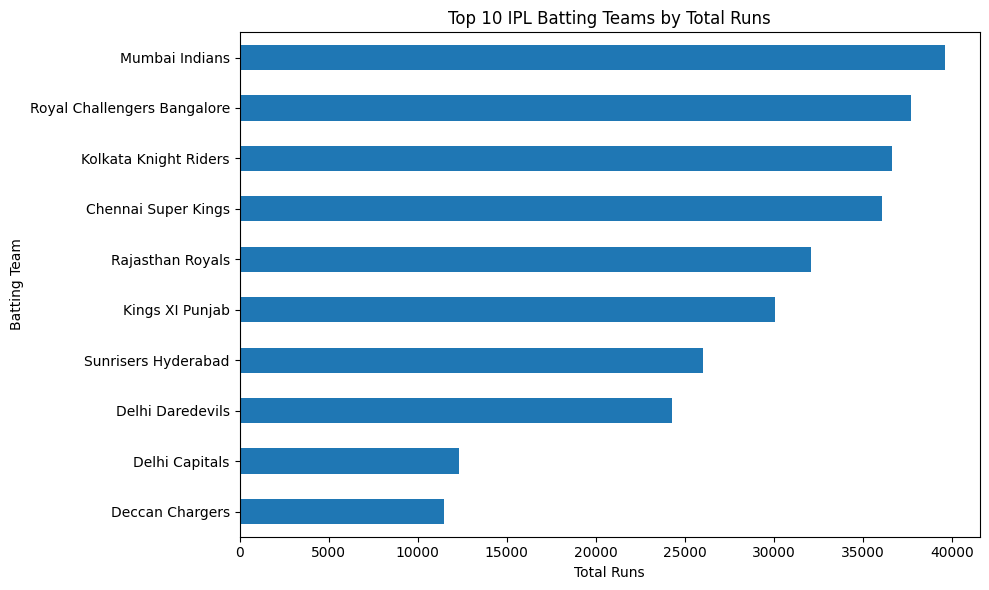

In [3]:
# Worksheet 1: Bar chart – batting teams
team_runs=df.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
team_runs.sort_values().plot(kind="barh")
plt.title("Top 10 IPL Batting Teams by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Batting Team")
plt.tight_layout()
plt.show()


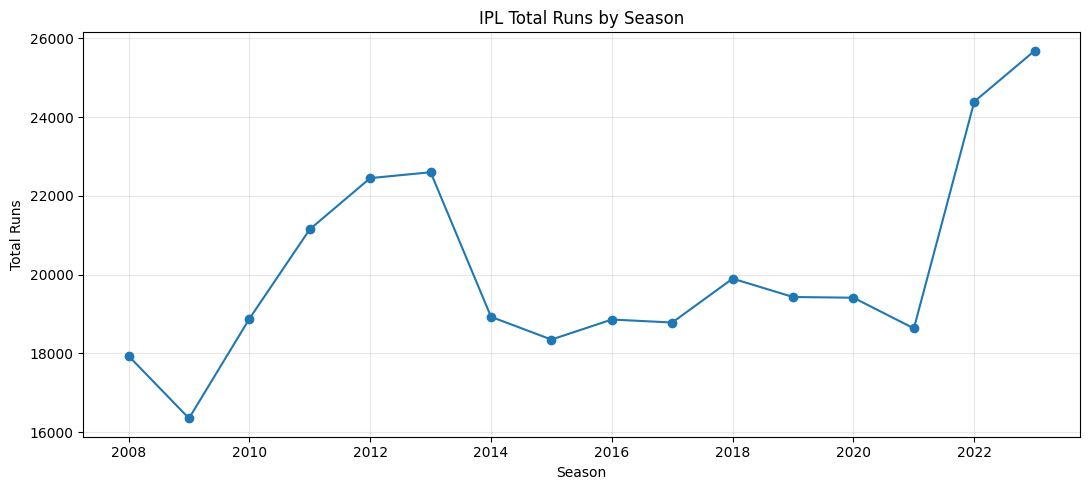

In [4]:
# Worksheet 2: Line chart – season trend
season_runs=df.groupby("season")["total_runs"].sum()

plt.figure(figsize=(11,5))
season_runs.plot(kind="line",marker="o")
plt.title("IPL Total Runs by Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()


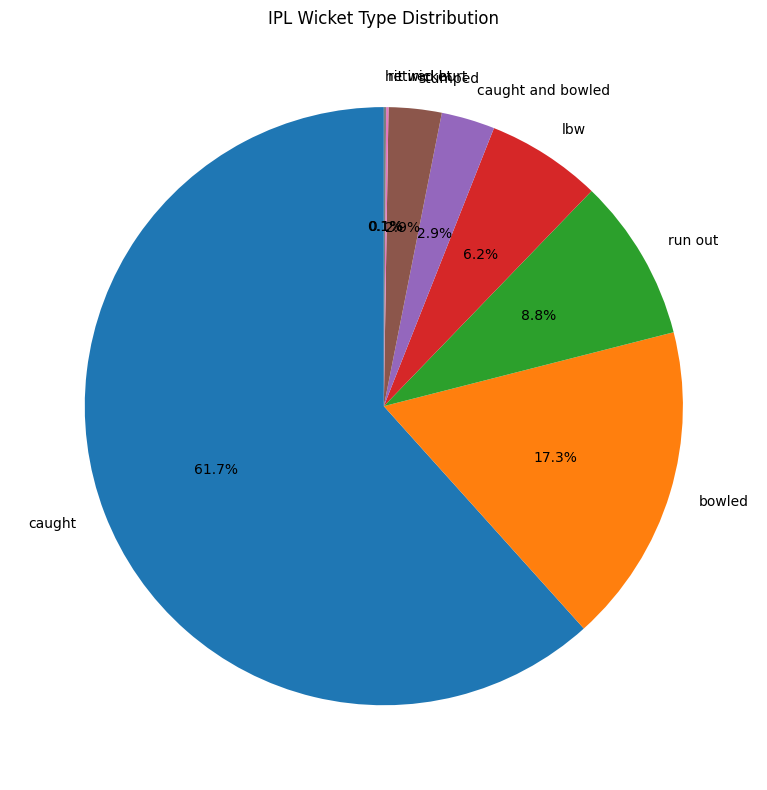

In [5]:
# Worksheet 3: Pie chart – wicket types
wickets=df.loc[df.wicket_type.notna(),"wicket_type"].value_counts().head(8)

plt.figure(figsize=(8,8))
plt.pie(wickets.values,labels=wickets.index,autopct="%1.1f%%",startangle=90)
plt.title("IPL Wicket Type Distribution")
plt.tight_layout()
plt.show()


In [6]:
# Worksheet 4: Table – top teams with calculated metrics
team_summary=df.groupby("batting_team").agg(
    Total_Runs=("total_runs","sum"),
    Boundary_Runs=("boundary_runs","sum"),
    Deliveries=("match_id","size")
).sort_values("Total_Runs",ascending=False).head(10)
display(team_summary)


,Total_Runs,Boundary_Runs,Deliveries
batting_team,,,
Mumbai Indians,39607,23000,29750
Royal Challengers Bangalore,37692,21524,28205
Kolkata Knight Riders,36664,21016,27920
Chennai Super Kings,36105,20360,26932
Rajasthan Royals,32100,18170,24410
Kings XI Punjab,30064,16974,22646
Sunrisers Hyderabad,26019,13936,19924
Delhi Daredevils,24296,13430,18786
Delhi Capitals,12327,6982,9305


In [7]:
# Tableau calculated-field examples
print("Total Runs = SUM([total_runs])")
print("Boundary Runs = SUM([boundary_runs])")
print("Matches = COUNTD([match_id])")
print("Wickets = SUM([is_wicket])  # create is_wicket as 1/0 in Tableau")


Total Runs = SUM([total_runs])
Boundary Runs = SUM([boundary_runs])
Matches = COUNTD([match_id])
Wickets = SUM([is_wicket])  # create is_wicket as 1/0 in Tableau


### Interactive Dashboard Design
Combine the four worksheets into a Tableau Dashboard:
- Team-wise Total Runs
- Season-wise Run Trend
- Wicket Type Distribution
- Top Team Summary Table

Add interactive filters for:
- **Season**
- **Batting Team**
- **Bowling Team**
- **Venue**

### Result
The IPL dataset was imported, transformed and analyzed, and the required Tableau-style worksheets were created with actual executed outputs. These worksheets can be combined in Tableau Desktop into the final interactive dashboard and report.

**Note:** The actual `.twb`/`.twbx` Tableau workbook must be created in Tableau Desktop.
